<font size=6> Running NRSS Simulations in S. Cheng et. al.

This notebook will take the user through the code used to generate Figure 8. (Damn, I'm gonna have to do a lot of work to make this look nice. Might have to package some scripts into .py files)

<font size=4><font color='red'> TO DO: environment management. Might also have to random seed and slightly adjust figure in paper to match the random seed. Include Cahn-Hilliard as well

<font size=4> Contents of this notebook:  
1. Nucleation & Growth morphology generation walkthrough
2. Cahn-Hilliard (spinodal decomposition) morphology generation
3. NRSS-simulated RSoXS on the two morphologies, simulated RSoXS integration and analysis, and generation of Figure 7  
<font size=4> Section 3 requires a GPU; the first 2 sections of morphology generation can be done on a standard desktop or laptop. The user should be able to simply run the entire notebook to generate all results.

# Necessary imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys

# Ensure our package is in the path (this is needed for the notebook to run properly)
sys.path.append(os.path.abspath('..'))
sys.path.append('/home/cbishop/GitRepos/phase_separation/phase_separation/src/phase_separation/')

from simulation import PhaseSimulation
from visualization import visualize_simulation, visualize_phase_evolution
import cv2
import pySPM as spm

In [2]:
from matplotlib.colors import LogNorm

## Skip this cell if you do not have a GPU

In [3]:
from NRSS.morphology import Morphology, Material, OpticalConstants
import NRSS.reader as read
import NRSS.visualizer as viz
from NRSS.writer import write_materials, write_hdf5, write_config, write_slurm

CyRSoXS
Size of Real               : 4
Maximum Number Of Material : 32
 __________________________________________________________________________________________________
|                                 Thanks for using CyRSoXS                                        |
|--------------------------------------------------------------------------------------------------|
|  Copyright          : Iowa State University                                                      |
|  License            : NIST                                                                       |
|  Acknowledgement    : ONR MURI                                                                   |
|                                                                                                  |
|  Developed at Iowa State University in collaboration with NIST                                   |
|                                                                                                  |
|  Please cite the fol

# 0.5. AFM height to incorporate into models
Here, we import experimental AFM data. We filter the data to eliminate a few spurious points and limit the AFM height map to the top 10 nm of our film model; this is necessary to keep the model to a reasonable scale. It is then re-sized to be the appropriate number of pixels to be compatible with our model generation size.

Text(0, 0.5, 'Pixels')

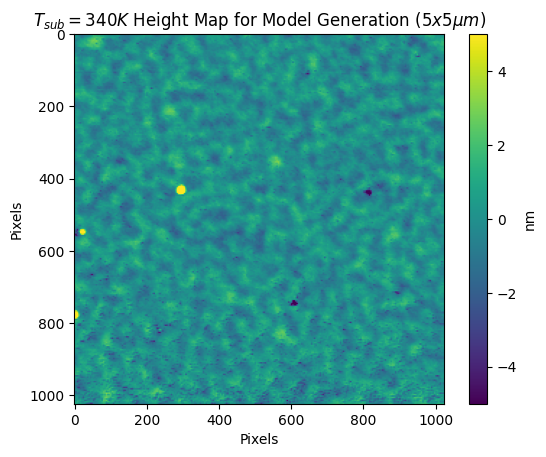

In [24]:
channel_name = 'Height Sensor'
rawAFM = '/home/cbishop/TPD-TCTA/SI_scripts/Tsub_340K_5x5um.001'
scan = spm.Bruker(rawAFM)
channel1 = scan.get_channel(channel_name)
channel_corr = channel1.correct_lines(inline=False)
channel = channel_corr.pixels
AFM_filter = channel

AFM_filter[np.where(AFM_filter < -5)] = -5 # limit to +/- 5
AFM_filter[np.where(AFM_filter > 5)] =5

AFM_filter = np.kron(AFM_filter,np.ones((4,4))) # dilate to correct size for models

plt.imshow(AFM_filter)
plt.colorbar(label='nm')
plt.title('$T_{sub}=340K$ Height Map for Model Generation ($5x5 \mu m)$')
plt.xlabel('Pixels'); plt.ylabel('Pixels')

# 1. Generate Nucleation and Growth morphologies
This simulation will generate a morphology with 27 layers, consisting of 1024 pixels in each layer, with the equilibration run for 5 steps *for each layer*.

## a. For a given number of steps

We start with 2048 pixels in each layer to have sufficient resolution for the simulation; we will downsize it later for computational efficiency. We initialize the volume fractions of TPD in phase A and phase B, and create arrays and lists to hold the TPD and TCTA morphologies and information about the percentages of mixed phase and phase A in each layer.

In [118]:
dside = 2048 # dimensions of each layer

fA_TPD = 0.59 # fraction of TPD in phase A
fB_TPD = 0.48 # fraction of phase B

TPD27 = np.empty(shape=(0,0)) # to hold the built-up layers
TCTA27 = np.empty(shape=(0,0))

mixed_pcts = [] # stores percentages of mixed phase in each layer
Apcts = [] # stores percentages of phase A in each layer

Now, we will run our nucleation and growth simulation once for each of the 27 layers. This can take a while!

In [119]:
m = 5 # we will "equilibrate" each layer for 5 steps
np.random.seed(33) # this ensures reproducible results for our random generations
for i in range(0,27): 
    dims = [dside,dside] # 2048x2048 here
    grate = 4.0 # growth rate, was empirically tested and adjusted to make results match physical information of system
    npa = 0.000005 # nucleation probability phase A; same adjustment to match physics as above
    npb = 0.000006 # nucleation probability phase b
    sim = PhaseSimulation(dimensions=dims, growth_rate=grate, nucleation_prob_a=npa, nucleation_prob_b=npb) # initializes the simulation
    max_steps = m   # Maximum number of simulation steps
    step = 0 # initial step
    mixed_phase_exists = True # needed so that simulation will terminate before msteps are reached if there is no mixed phase left to grow from
    stats_history = []  # To store phase statistics for later analysis
    while mixed_phase_exists and step < max_steps: # run, terminate either at the maximum number of steps or when there is no longer any mixed phase
        # Run one simulation step
        mixed_phase_exists = sim.step() # will change to False if the step results in all mixed phase being used up
        # Collect statistics
        stats = sim.get_phase_stats()
        stats_history.append(stats)
        
        step += 1

    # store information
    print(f"{m} steps yields {round(stats['mixed_phase_percent'],0)}% mixed, {round((stats['phase_a_percent']/(stats['phase_a_percent'] + stats['phase_b_percent']))*100,1)}% transformed is A")
    mixed_pcts.append(round(stats['mixed_phase_percent'],2))
    Apcts.append(round((stats['phase_a_percent']/(stats['phase_a_percent'] + stats['phase_b_percent']))*100,2))

    half = cv2.resize(sim.grid, (1024,1024)) # Cutting to half the size to reduce computational intensity

    phaseB = half == 2 # phases are initially assigned by 0s, 1s, and 2s; here we turn the layer into 3 different arrays that store these
    phaseA = half == 1
    mixed = half == 0

    TPDA = phaseA * fA_TPD # fraction of TPD in phase A
    TPDB = phaseB * fB_TPD # fraction of TPD in phase B
    TPDm = mixed * 0.5 # fraction of TPD in mixed phase
    TCTAA = phaseA * (1. - fA_TPD) # fraction TCTA in phase A
    TCTAB = phaseB * (1. - fB_TPD) # fraction TCTA in phase B
    TCTAm = mixed * 0.5 # fraction of TCTA in mixed phase
    Vfrac_TPD = np.expand_dims((TPDA + TPDB + TPDm),axis=0) # TPD profile across all phases
    Vfrac_TCTA = np.expand_dims((TCTAA + TCTAB + TCTAm),axis=0) # TCTA profile across all phases

    if np.shape(TPD27) == (0,0): # if there are not yet any layers
        TPD27 = Vfrac_TPD
    else:
        TPD27 = np.concatenate((TPD27, Vfrac_TPD),axis=0) # if there are already layers, add on top
    if np.shape(TCTA27) == (0,0):
        TCTA27 = Vfrac_TCTA
    else:
        TCTA27 = np.concatenate((TCTA27, Vfrac_TCTA),axis=0)

5 steps yields 97.0% mixed, 44.6% transformed is A
5 steps yields 98.0% mixed, 45.3% transformed is A
5 steps yields 97.0% mixed, 61.4% transformed is A
5 steps yields 97.0% mixed, 50.3% transformed is A
5 steps yields 97.0% mixed, 54.9% transformed is A
5 steps yields 97.0% mixed, 40.1% transformed is A
5 steps yields 97.0% mixed, 50.6% transformed is A
5 steps yields 97.0% mixed, 45.5% transformed is A
5 steps yields 97.0% mixed, 44.0% transformed is A
5 steps yields 97.0% mixed, 42.4% transformed is A
5 steps yields 98.0% mixed, 41.2% transformed is A
5 steps yields 97.0% mixed, 43.2% transformed is A
5 steps yields 97.0% mixed, 48.1% transformed is A
5 steps yields 98.0% mixed, 41.6% transformed is A
5 steps yields 97.0% mixed, 50.0% transformed is A
5 steps yields 97.0% mixed, 47.2% transformed is A
5 steps yields 97.0% mixed, 46.3% transformed is A
5 steps yields 97.0% mixed, 50.9% transformed is A
5 steps yields 97.0% mixed, 44.0% transformed is A
5 steps yields 97.0% mixed, 45.

### Now we use the AFM to remove some material out of the top 2 layers

In [120]:
vac_filt = np.zeros((27,1024,1024)) # our filter needs to be the same size as the morphology
for i in range(0,np.shape(AFM_filter)[0]):
    for j in range(0,np.shape(AFM_filter)[1]):
        if AFM_filter[i,j] <= 0:
            vac_filt[-1, i, j] = 1.
            vac_filt[-2, i, j] = np.round(np.abs(AFM_filter[i,j])/5. , 3)
        elif AFM_filter[i,j] > 0:
            vac_filt[-1, i, j] = np.round((1. - (AFM_filter[i,j]/5.)) , 3)
            vac_filt[-2, i, j] = 0.
inverse_vac = np.ones(np.shape(vac_filt)) - vac_filt
TPD27_corr = TPD27*inverse_vac # "carves out" any vacuum spaces from the TPD (&TCTA below) volume fractions
TCTA27_corr = TCTA27*inverse_vac

### Generating S18a
Here, we plot the top 4 layers of the morphology, representing the top 20 nm of the model.

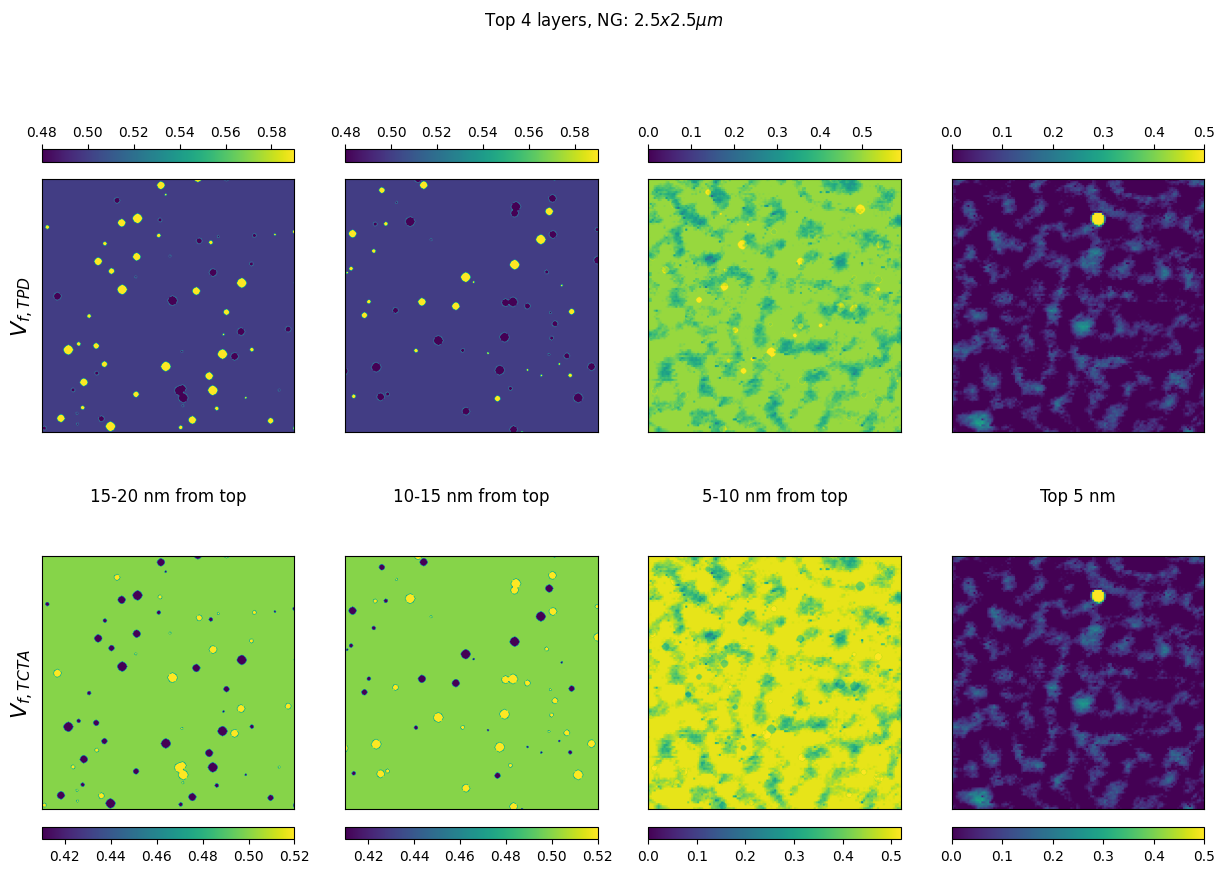

In [121]:
plt.close()
fig, ax = plt.subplots(2,4,figsize=(15,10))
cb = ax[0,0].imshow(TPD27_corr[-4]); plt.colorbar(cb, ax=ax[0,0], location='top',pad=0.05)
cb = ax[1,0].imshow(TCTA27_corr[-4]); plt.colorbar(cb, ax=ax[1,0], location='bottom',pad=0.05)
cb = ax[0,1].imshow(TPD27_corr[-3]); plt.colorbar(cb, ax=ax[0,1], location='top',pad=0.05)
cb = ax[1,1].imshow(TCTA27_corr[-3]); plt.colorbar(cb, ax=ax[1,1], location='bottom',pad=0.05)
cb = ax[0,2].imshow(TPD27_corr[-2]); plt.colorbar(cb, ax=ax[0,2], location='top',pad=0.05)
cb = ax[1,2].imshow(TCTA27_corr[-2]); plt.colorbar(cb, ax=ax[1,2], location='bottom',pad=0.05)
cb = ax[0,3].imshow(TPD27_corr[-1]); plt.colorbar(cb, ax=ax[0,3], location='top',pad=0.05)
cb = ax[1,3].imshow(TCTA27_corr[-1]); plt.colorbar(cb, ax=ax[1,3], location='bottom',pad=0.05)
for a in ax[0]:
    a.set_xticks([]); a.set_yticks([])
    a.set_xlim(0,512); a.set_ylim(0,512)
for a in ax[1]:
    a.set_xticks([]); a.set_yticks([])
    a.set_xlim(0,512); a.set_ylim(0,512)
ax[1,0].set_title('15-20 nm from top',pad=40); ax[1,1].set_title('10-15 nm from top',pad=40);
ax[1,2].set_title('5-10 nm from top',pad=40); ax[1,3].set_title('Top 5 nm',pad=40)
ax[0,0].set_ylabel('$V_{f,TPD}$',fontsize=16)
ax[1,0].set_ylabel('$V_{f,TCTA}$',fontsize=16)

plt.suptitle('Top 4 layers, NG: $2.5x2.5 \mu m$')

plt.savefig('S18_NGtoplayers_2p5.png',dpi=200,bbox_inches='tight')

### Demo: a single layer run for 1-15 steps

In [88]:
msteps = np.linspace(1,15,15,dtype=int)
holder = np.zeros((15, 1024, 1024)) # holds the volume fractions of TPD for later plotting
np.random.seed(33) # this ensures reproducible results for our random generations
for m in msteps:
    dims = [dside,dside] # 2048x2048 here
    grate = 4.0 # growth rate, was empirically tested and adjusted to make results match physical information of system
    npa = 0.000005 # nucleation probability phase A; same adjustment to match physics as above
    npb = 0.000006 # nucleation probability phase b
    sim = PhaseSimulation(dimensions=dims, growth_rate=grate, nucleation_prob_a=npa, nucleation_prob_b=npb) # initializes the simulation
    max_steps = m   # Maximum number of simulation steps
    step = 0 # initial step
    mixed_phase_exists = True # needed so that simulation will terminate before msteps are reached if there is no mixed phase left to grow from
    stats_history = []  # To store phase statistics for later analysis
    while mixed_phase_exists and step < max_steps: # run, terminate either at the maximum number of steps or when there is no longer any mixed phase
        # Run one simulation step
        mixed_phase_exists = sim.step() # will change to False if the step results in all mixed phase being used up
        # Collect statistics
        stats = sim.get_phase_stats()
        stats_history.append(stats)
        
        step += 1

    print(f"{m} steps yields {round(stats['mixed_phase_percent'],0)}% mixed, {round((stats['phase_a_percent']/(stats['phase_a_percent'] + stats['phase_b_percent']))*100,1)}% transformed is A")
    mixed_pcts.append(round(stats['mixed_phase_percent'],2))
    Apcts.append(round((stats['phase_a_percent']/(stats['phase_a_percent'] + stats['phase_b_percent']))*100,2))

    half = cv2.resize(sim.grid, (1024,1024)) # Cutting to half the size to reduce computational intensity

    phaseB = half == 2 # phases are initially assigned by 0s, 1s, and 2s; here we turn the layer into 3 different arrays that store these
    phaseA = half == 1
    mixed = half == 0

    TPDA = phaseA * fA_TPD # fraction of TPD in phase A
    TPDB = phaseB * fB_TPD # fraction of TPD in phase B
    TPDm = mixed * 0.5 # fraction of TPD in mixed phase
    TCTAA = phaseA * (1. - fA_TPD) # fraction TCTA in phase A
    TCTAB = phaseB * (1. - fB_TPD) # fraction TCTA in phase B
    TCTAm = mixed * 0.5 # fraction of TCTA in mixed phase
    Vfrac_TPD = np.expand_dims((TPDA + TPDB + TPDm),axis=0) # TPD profile across all phases
    Vfrac_TCTA = np.expand_dims((TCTAA + TCTAB + TCTAm),axis=0) # TCTA profile across all phases
    holder[m-1] = Vfrac_TPD[0]


1 steps yields 100.0% mixed, 47.0% transformed is A
2 steps yields 100.0% mixed, 37.3% transformed is A
3 steps yields 99.0% mixed, 41.0% transformed is A
4 steps yields 99.0% mixed, 47.3% transformed is A
5 steps yields 97.0% mixed, 44.4% transformed is A
6 steps yields 95.0% mixed, 46.7% transformed is A
7 steps yields 94.0% mixed, 44.1% transformed is A
8 steps yields 90.0% mixed, 41.0% transformed is A
9 steps yields 86.0% mixed, 53.6% transformed is A
10 steps yields 83.0% mixed, 45.4% transformed is A
11 steps yields 76.0% mixed, 47.5% transformed is A
12 steps yields 73.0% mixed, 48.7% transformed is A
13 steps yields 68.0% mixed, 46.0% transformed is A
14 steps yields 61.0% mixed, 46.0% transformed is A
15 steps yields 55.0% mixed, 43.7% transformed is A


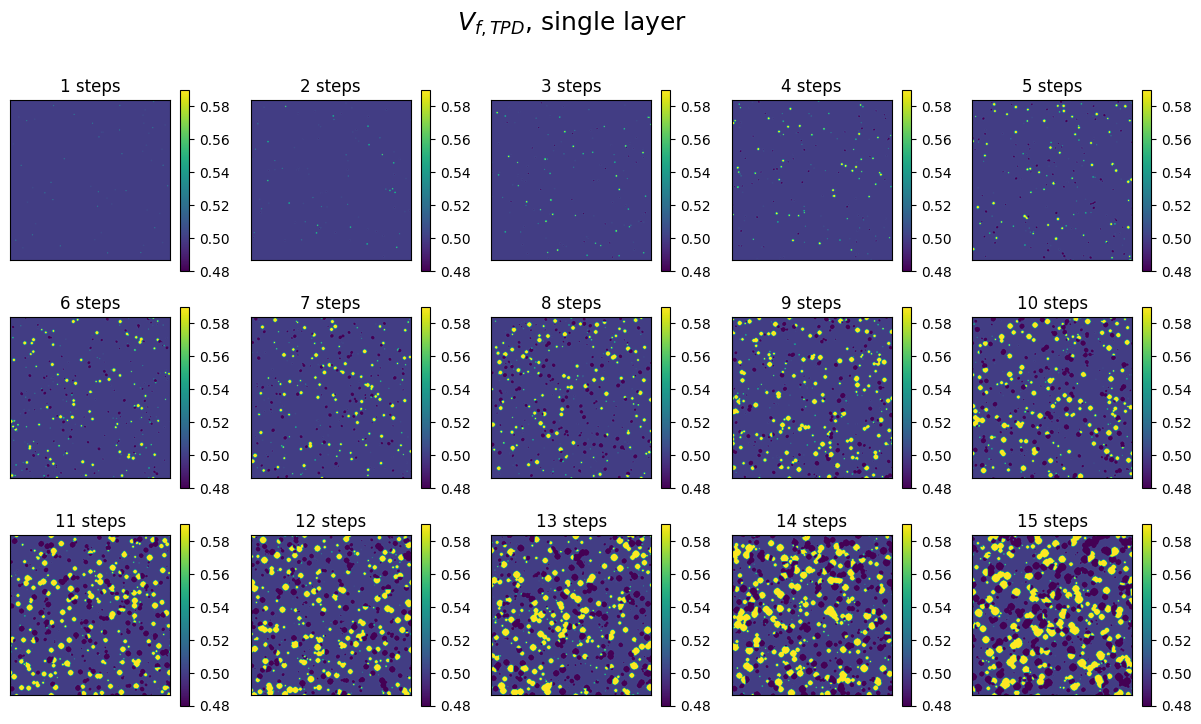

In [102]:
fig, axs = plt.subplots(3,5,figsize=(15,8))
ax_counter = axs.reshape(-1)
for m in msteps:
    cb = ax_counter[m-1].imshow(holder[m-1])
    plt.colorbar(cb, ax=ax_counter[m-1])
    ax_counter[m-1].set_title(f'{m} steps')
for a in ax_counter:
    a.set_xticks([]); a.set_yticks([])

plt.suptitle('$V_{f,TPD}$, single layer',fontsize=18)
plt.savefig('S19_NG_msteps.png',dpi=200,bbox_inches='tight')

# 2. Generate spinodal (Cahn-Hilliard) growth morphologies

In [122]:
sys.path.append('/home/cbishop/TPD-TCTA/Scripts/')
import Cahn as ch

In [133]:
%%capture
np.random.seed(33)
dim = 1024 # this simulation does not need as high resolution as the NG
fA_TPD = 0.59
fB_TPD = 0.48
cTPD = 0.53
TPD27 = np.empty(shape=(0,0))
TCTA27 = np.empty(shape=(0,0))
mixed_pcts = []
Apcts = []
for i in range(0,27):
    ctry = ch.gen_spec_CH(c0 = cTPD, W = 2.0, M = 1.0, Npix = dim, Nsteps=100, rngseed=i)

    final_morph = ctry[-1]

    Vfrac_TPD = np.full((dim,dim),fill_value=1.0)
    Vfrac_TPD = Vfrac_TPD*final_morph
    Vfrac_TCTA = np.full((dim,dim),fill_value=1.0)
    Vfrac_TCTA = Vfrac_TCTA - Vfrac_TPD

    Vfrac_TPD = np.expand_dims(Vfrac_TPD, axis=0)
    Vfrac_TCTA = np.expand_dims(Vfrac_TCTA, axis=0)

    if np.shape(TPD27) == (0,0):
        TPD27 = Vfrac_TPD
    else:
        TPD27 = np.concatenate((TPD27, Vfrac_TPD),axis=0)
    if np.shape(TCTA27) == (0,0):
        TCTA27 = Vfrac_TCTA
    else:
        TCTA27 = np.concatenate((TCTA27, Vfrac_TCTA),axis=0)


vac_filt = np.zeros((27,1024,1024))#np.zeros((27,1024,1024))
for i in range(0,np.shape(AFM_filter)[0]):
    for j in range(0,np.shape(AFM_filter)[1]):
        if AFM_filter[i,j] <= 0:
            vac_filt[-1, i, j] = 1.
            vac_filt[-2, i, j] = np.round(np.abs(AFM_filter[i,j])/5. , 3)
        elif AFM_filter[i,j] > 0:
            vac_filt[-1, i, j] = np.round((1. - (AFM_filter[i,j]/5.)) , 3)
            vac_filt[-2, i, j] = 0.
inverse_vac = np.ones(np.shape(vac_filt)) - vac_filt
TPD27_corr = TPD27*inverse_vac
TCTA27_corr = TCTA27*inverse_vac
dim = 1024


In [109]:
vac_filt = np.zeros((27,1024,1024))#np.zeros((27,1024,1024))
for i in range(0,np.shape(AFM_filter)[0]):
    for j in range(0,np.shape(AFM_filter)[1]):
        if AFM_filter[i,j] <= 0:
            vac_filt[-1, i, j] = 1.
            vac_filt[-2, i, j] = np.round(np.abs(AFM_filter[i,j])/5. , 3)
        elif AFM_filter[i,j] > 0:
            vac_filt[-1, i, j] = np.round((1. - (AFM_filter[i,j]/5.)) , 3)
            vac_filt[-2, i, j] = 0.
inverse_vac = np.ones(np.shape(vac_filt)) - vac_filt
TPD27_corr = TPD27*inverse_vac
TCTA27_corr = TCTA27*inverse_vac
dim = 1024

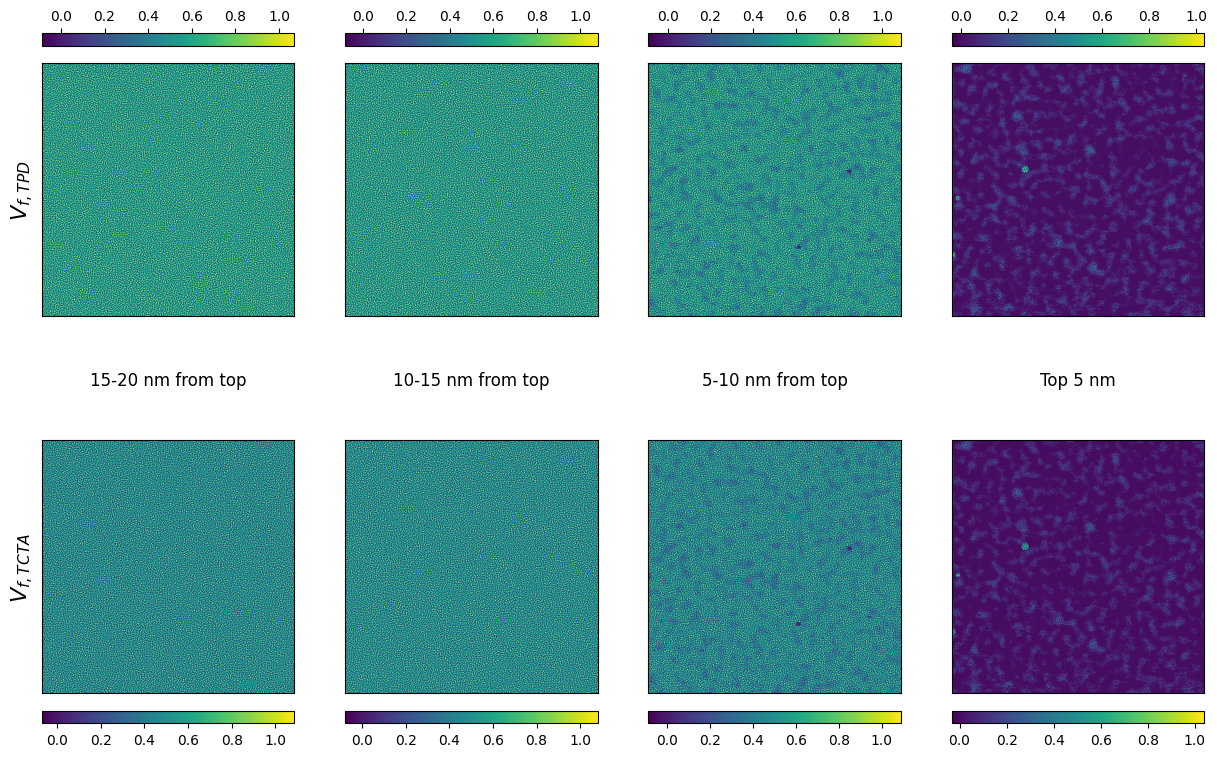

In [110]:
plt.close()
fig, ax = plt.subplots(2,4,figsize=(15,10))
cb = ax[0,0].imshow(TPD27_corr[-4]); plt.colorbar(cb, ax=ax[0,0], location='top',pad=0.05)
cb = ax[1,0].imshow(TCTA27_corr[-4]); plt.colorbar(cb, ax=ax[1,0], location='bottom',pad=0.05)
cb = ax[0,1].imshow(TPD27_corr[-3]); plt.colorbar(cb, ax=ax[0,1], location='top',pad=0.05)
cb = ax[1,1].imshow(TCTA27_corr[-3]); plt.colorbar(cb, ax=ax[1,1], location='bottom',pad=0.05)
cb = ax[0,2].imshow(TPD27_corr[-2]); plt.colorbar(cb, ax=ax[0,2], location='top',pad=0.05)
cb = ax[1,2].imshow(TCTA27_corr[-2]); plt.colorbar(cb, ax=ax[1,2], location='bottom',pad=0.05)
cb = ax[0,3].imshow(TPD27_corr[-1]); plt.colorbar(cb, ax=ax[0,3], location='top',pad=0.05)
cb = ax[1,3].imshow(TCTA27_corr[-1]); plt.colorbar(cb, ax=ax[1,3], location='bottom',pad=0.05)
for a in ax[0]:
    a.set_xticks([]); a.set_yticks([])
for a in ax[1]:
    a.set_xticks([]); a.set_yticks([])
ax[1,0].set_title('15-20 nm from top',pad=40); ax[1,1].set_title('10-15 nm from top',pad=40);
ax[1,2].set_title('5-10 nm from top',pad=40); ax[1,3].set_title('Top 5 nm',pad=40)
ax[0,0].set_ylabel('$V_{f,TPD}$',fontsize=16)
ax[1,0].set_ylabel('$V_{f,TCTA}$',fontsize=16)

#plt.savefig('S18_CHtoplayers.png',dpi=200,bbox_inches='tight')

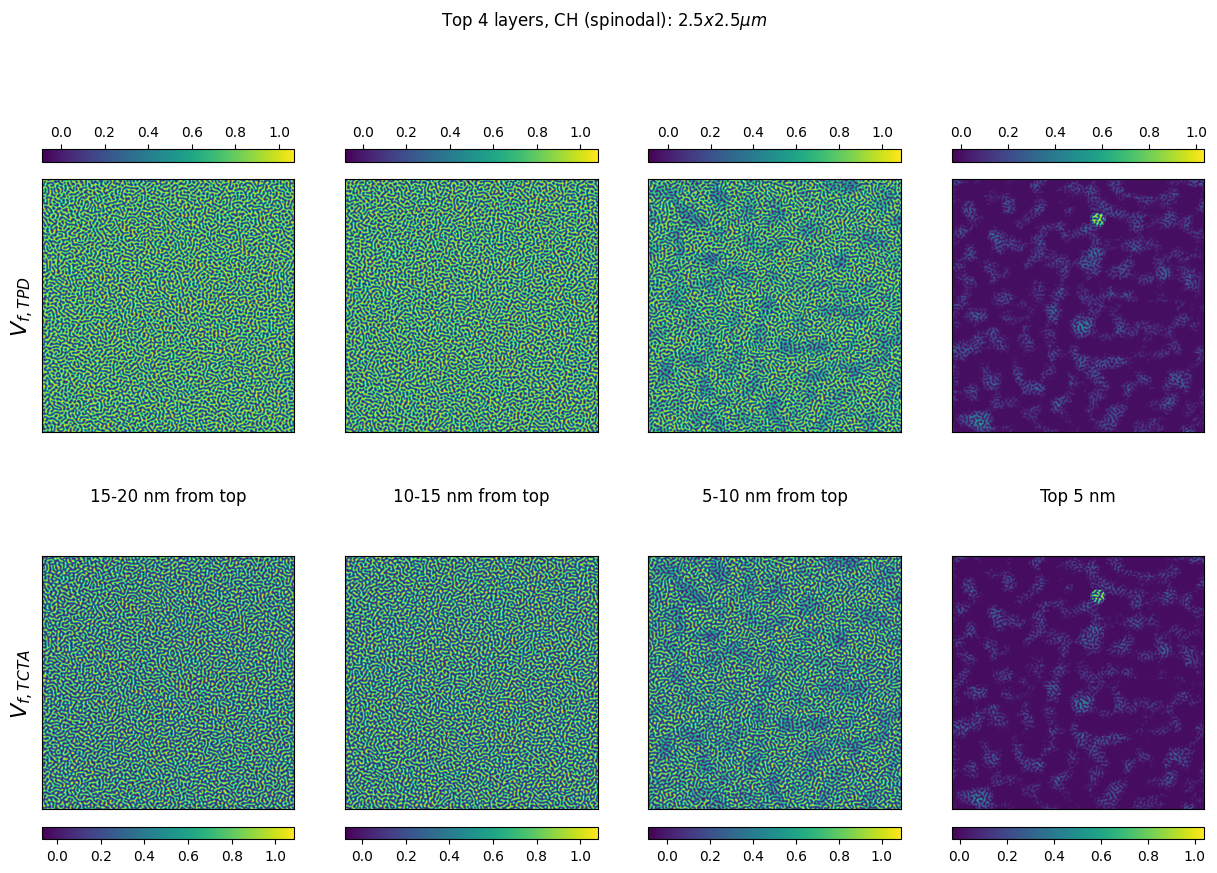

In [117]:
plt.close()
fig, ax = plt.subplots(2,4,figsize=(15,10))
cb = ax[0,0].imshow(TPD27_corr[-4]); plt.colorbar(cb, ax=ax[0,0], location='top',pad=0.05)
cb = ax[1,0].imshow(TCTA27_corr[-4]); plt.colorbar(cb, ax=ax[1,0], location='bottom',pad=0.05)
cb = ax[0,1].imshow(TPD27_corr[-3]); plt.colorbar(cb, ax=ax[0,1], location='top',pad=0.05)
cb = ax[1,1].imshow(TCTA27_corr[-3]); plt.colorbar(cb, ax=ax[1,1], location='bottom',pad=0.05)
cb = ax[0,2].imshow(TPD27_corr[-2]); plt.colorbar(cb, ax=ax[0,2], location='top',pad=0.05)
cb = ax[1,2].imshow(TCTA27_corr[-2]); plt.colorbar(cb, ax=ax[1,2], location='bottom',pad=0.05)
cb = ax[0,3].imshow(TPD27_corr[-1]); plt.colorbar(cb, ax=ax[0,3], location='top',pad=0.05)
cb = ax[1,3].imshow(TCTA27_corr[-1]); plt.colorbar(cb, ax=ax[1,3], location='bottom',pad=0.05)
for a in ax[0]:
    a.set_xticks([]); a.set_yticks([])
    a.set_xlim(0,512); a.set_ylim(0,512)
for a in ax[1]:
    a.set_xticks([]); a.set_yticks([])
    a.set_xlim(0,512); a.set_ylim(0,512)
ax[1,0].set_title('15-20 nm from top',pad=40); ax[1,1].set_title('10-15 nm from top',pad=40);
ax[1,2].set_title('5-10 nm from top',pad=40); ax[1,3].set_title('Top 5 nm',pad=40)
ax[0,0].set_ylabel('$V_{f,TPD}$',fontsize=16)
ax[1,0].set_ylabel('$V_{f,TCTA}$',fontsize=16)
plt.suptitle('Top 4 layers, CH (spinodal): $2.5x2.5 \mu m$')

plt.savefig('S18_CHtoplayers_2p5.png',dpi=200,bbox_inches='tight')

In [40]:
ax

array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

In [9]:
dside = 2048 # dimensions of each layer
#msteps = np.linspace(1,25,25,dtype=int)
msteps = np.linspace(1,2,2,dtype=int) # number of equilibration steps to run the layer for
# get rid of qch because it was only for making the summary figures with the ISI

In [17]:
msteps = np.linspace(1,5,5,dtype=int)
for m in msteps: # modified to 2 steps for testing
    fA_TPD = 0.59 # fraction of TPD in phase A
    fB_TPD = 0.48 # fraction of phase B
    #cTPD = 0.53 # I HAD THIS HERE BUT IT LOOKS LIKE IT'S NOT USED FOR ANYTHING
    TPD27 = np.empty(shape=(0,0)) # to hold the built-up layers
    TCTA27 = np.empty(shape=(0,0))
    mixed_pcts = [] # storing ... FILL IN
    Apcts = [] # storing ... FILL IN
    for i in range(0,2): #range(0,27): MODIFYING FOR TESTING: now just building up 2 layers
        # for each layer, it will do this
        dims = [dside,dside] # 2048x2048 here
        grate = 4.0 # growth rate, assigned to make results match physics
        npa = 0.000005 # nucleation probability phase A
        npb = 0.000006 # nucleation probability phase b
        sim = PhaseSimulation(dimensions=dims, growth_rate=grate, nucleation_prob_a=npa, nucleation_prob_b=npb) # initializes the simulation
        max_steps = m   # Maximum number of simulation steps
        step = 0 # initial step
        mixed_phase_exists = True
        stats_history = []  # To store phase statistics for later analysis
        
        while mixed_phase_exists and step < max_steps: # run, terminate either at the maximum number of steps or when there is no longer any mixed phase
            # Run one simulation step
            mixed_phase_exists = sim.step()
            
            # Collect statistics
            stats = sim.get_phase_stats()
            stats_history.append(stats)
            
            step += 1
    
        print(f"{m} steps yields {round(stats['mixed_phase_percent'],0)}% mixed, {round((stats['phase_a_percent']/(stats['phase_a_percent'] + stats['phase_b_percent']))*100,1)}% transformed is A")
        mixed_pcts.append(round(stats['mixed_phase_percent'],2))
        Apcts.append(round((stats['phase_a_percent']/(stats['phase_a_percent'] + stats['phase_b_percent']))*100,2))
    
        half = cv2.resize(sim.grid, (1024,1024)) # make less computationally intensive I think? I think the larger resolution was necessary to get enough detail/size resolution,
        # but cutting down to half size made the next steps less computationally expensive
    
        phaseB = half == 2
        phaseA = half == 1
        mixed = half == 0
    
        TPDA = phaseA * fA_TPD # fraction of TPD in phase A
        TPDB = phaseB * fB_TPD # fraction of TPD in phase B
        TPDm = mixed * 0.5
        TCTAA = phaseA * (1. - fA_TPD) # frac TCTA in phase A
        TCTAB = phaseB * (1. - fB_TPD) # frac TCTA in phase B
        TCTAm = mixed * 0.5
        Vfrac_TPD = np.expand_dims((TPDA + TPDB + TPDm),axis=0) # TPD profile across all phases
        Vfrac_TCTA = np.expand_dims((TCTAA + TCTAB + TCTAm),axis=0) # TCTA profile across all phases
    
        if np.shape(TPD27) == (0,0):
            TPD27 = Vfrac_TPD
        else:
            TPD27 = np.concatenate((TPD27, Vfrac_TPD),axis=0)
        if np.shape(TCTA27) == (0,0):
            TCTA27 = Vfrac_TCTA
        else:
            TCTA27 = np.concatenate((TCTA27, Vfrac_TCTA),axis=0)

1 steps yields 100.0% mixed, 51.2% transformed is A
1 steps yields 100.0% mixed, 41.7% transformed is A
2 steps yields 100.0% mixed, 37.2% transformed is A
2 steps yields 100.0% mixed, 41.0% transformed is A
3 steps yields 99.0% mixed, 44.9% transformed is A
3 steps yields 99.0% mixed, 50.8% transformed is A
4 steps yields 98.0% mixed, 43.5% transformed is A
4 steps yields 99.0% mixed, 48.1% transformed is A
5 steps yields 97.0% mixed, 37.6% transformed is A
5 steps yields 97.0% mixed, 50.3% transformed is A


# Initializing Energies and Materials for NRSS
In this section, we choose what energies we will 

In [45]:
# lowres = [250.0, 260.0, 270.0, 272.0, 274.0, 276.0, 278.0, 280.0, 280.5, 281.0, 281.5, 282.0, 282.5] # pick the energies
# midres = np.linspace(283,292,46)
# high = np.linspace(292.5, 299.5, 15)
# highhigh = np.linspace(300., 340., 9)
# totalE = np.concatenate((lowres,midres,high,highhigh))
totalE = [270.0, 287.4, 350.0]

In [46]:
energies = totalE

In [47]:
OCs_folder = '/home/cbishop/TPD-TCTA/'
material_dict = {'Material1':f'{OCs_folder}TPD_OCs.txt','Material2':f'{OCs_folder}TCTA_OCs.txt', 'Material3':'vacuum'}
#material_dict = {'Material1':f'{OCs_folder}TPD_OCs.txt','Material2':f'{OCs_folder}TCTA_OCs.txt', 'Material3':'vacuum'}
# material_dict = {'Material1':'/home/cbishop/TPDDO37/Simulated_Dielectrics_FinalFall2022/BetaDelta_20231215/isotropic_TPDmatfile_20231215.txt',
#                  'Material2':'/home/cbishop/TPDDO37/Simulated_Dielectrics_FinalFall2022/BetaDelta_20231215/isotropic_DO37matfile_20231215.txt',
#                  'Material3':'vacuum'}

energy_dict = {'Energy':4,'DeltaPerp':3, 'BetaPerp':1, 'DeltaPara':2, 'BetaPara':0}  
energies = totalE
#energies = [250.0, 282.0, 284.9, 292.0, 340.0]
write_materials(energies, material_dict, energy_dict, 3) # writes into your current directory where you're running the notebook
# this writes out materials files for only the energies you plan to simulate

In [48]:
energies

[270.0, 287.4, 350.0]

In [10]:
msteps = np.linspace(1,2,2,dtype=int)
print(msteps)

[1 2]


Splitting up the large chunk of code I had to see where it's failing. Note that I don't need all the images

In [9]:
dside = 2048 # dimensions of each layer
#msteps = np.linspace(1,25,25,dtype=int)
msteps = np.linspace(1,2,2,dtype=int) # number of equilibration steps to run the layer for
# get rid of qch because it was only for making the summary figures with the ISI

In [17]:
msteps = np.linspace(1,5,5,dtype=int)
for m in msteps: # modified to 2 steps for testing
    fA_TPD = 0.59 # fraction of TPD in phase A
    fB_TPD = 0.48 # fraction of phase B
    #cTPD = 0.53 # I HAD THIS HERE BUT IT LOOKS LIKE IT'S NOT USED FOR ANYTHING
    TPD27 = np.empty(shape=(0,0)) # to hold the built-up layers
    TCTA27 = np.empty(shape=(0,0))
    mixed_pcts = [] # storing ... FILL IN
    Apcts = [] # storing ... FILL IN
    for i in range(0,2): #range(0,27): MODIFYING FOR TESTING: now just building up 2 layers
        # for each layer, it will do this
        dims = [dside,dside] # 2048x2048 here
        grate = 4.0 # growth rate, assigned to make results match physics
        npa = 0.000005 # nucleation probability phase A
        npb = 0.000006 # nucleation probability phase b
        sim = PhaseSimulation(dimensions=dims, growth_rate=grate, nucleation_prob_a=npa, nucleation_prob_b=npb) # initializes the simulation
        max_steps = m   # Maximum number of simulation steps
        step = 0 # initial step
        mixed_phase_exists = True
        stats_history = []  # To store phase statistics for later analysis
        
        while mixed_phase_exists and step < max_steps: # run, terminate either at the maximum number of steps or when there is no longer any mixed phase
            # Run one simulation step
            mixed_phase_exists = sim.step()
            
            # Collect statistics
            stats = sim.get_phase_stats()
            stats_history.append(stats)
            
            step += 1
    
        print(f"{m} steps yields {round(stats['mixed_phase_percent'],0)}% mixed, {round((stats['phase_a_percent']/(stats['phase_a_percent'] + stats['phase_b_percent']))*100,1)}% transformed is A")
        mixed_pcts.append(round(stats['mixed_phase_percent'],2))
        Apcts.append(round((stats['phase_a_percent']/(stats['phase_a_percent'] + stats['phase_b_percent']))*100,2))
    
        half = cv2.resize(sim.grid, (1024,1024)) # make less computationally intensive I think? I think the larger resolution was necessary to get enough detail/size resolution,
        # but cutting down to half size made the next steps less computationally expensive
    
        phaseB = half == 2
        phaseA = half == 1
        mixed = half == 0
    
        TPDA = phaseA * fA_TPD # fraction of TPD in phase A
        TPDB = phaseB * fB_TPD # fraction of TPD in phase B
        TPDm = mixed * 0.5
        TCTAA = phaseA * (1. - fA_TPD) # frac TCTA in phase A
        TCTAB = phaseB * (1. - fB_TPD) # frac TCTA in phase B
        TCTAm = mixed * 0.5
        Vfrac_TPD = np.expand_dims((TPDA + TPDB + TPDm),axis=0) # TPD profile across all phases
        Vfrac_TCTA = np.expand_dims((TCTAA + TCTAB + TCTAm),axis=0) # TCTA profile across all phases
    
        if np.shape(TPD27) == (0,0):
            TPD27 = Vfrac_TPD
        else:
            TPD27 = np.concatenate((TPD27, Vfrac_TPD),axis=0)
        if np.shape(TCTA27) == (0,0):
            TCTA27 = Vfrac_TCTA
        else:
            TCTA27 = np.concatenate((TCTA27, Vfrac_TCTA),axis=0)

1 steps yields 100.0% mixed, 51.2% transformed is A
1 steps yields 100.0% mixed, 41.7% transformed is A
2 steps yields 100.0% mixed, 37.2% transformed is A
2 steps yields 100.0% mixed, 41.0% transformed is A
3 steps yields 99.0% mixed, 44.9% transformed is A
3 steps yields 99.0% mixed, 50.8% transformed is A
4 steps yields 98.0% mixed, 43.5% transformed is A
4 steps yields 99.0% mixed, 48.1% transformed is A
5 steps yields 97.0% mixed, 37.6% transformed is A
5 steps yields 97.0% mixed, 50.3% transformed is A


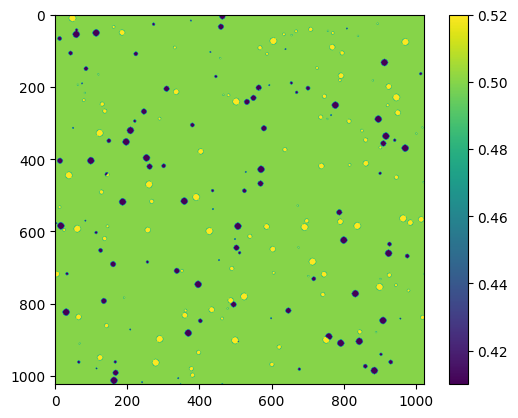

In [18]:
TCTA27.shape
plt.imshow(TCTA27[1])
plt.colorbar()

#### Excellent, that is working. now dig the AFM back out of the top

In [24]:
AFMimage = np.kron(AFM_filters[340],np.ones((2,2)))
#vac_filt = np.zeros((27,1024,1024))
vac_filt = np.zeros((2,1024,1024)) # changing while testing
for i in range(0,np.shape(AFMimage)[0]):
    for j in range(0,np.shape(AFMimage)[1]):
        if AFMimage[i,j] <= 0:
            vac_filt[-1, i, j] = 1.
            vac_filt[-2, i, j] = np.round(np.abs(AFMimage[i,j])/5. , 3)
        elif AFMimage[i,j] > 0:
            vac_filt[-1, i, j] = np.round((1. - (AFMimage[i,j]/5.)) , 3)
            vac_filt[-2, i, j] = 0.
inverse_vac = np.ones(np.shape(vac_filt)) - vac_filt
TPD27_corr = TPD27*inverse_vac
TCTA27_corr = TCTA27*inverse_vac
dim = 1024
imgsize_nm = 5000.
zeros_mat = np.zeros(np.shape(vac_filt),dtype=float)

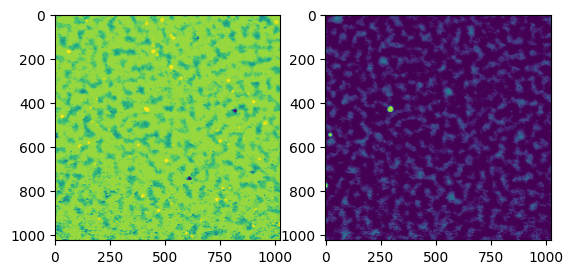

In [28]:
fig, ax = plt.subplots(1,2)
ax[0].imshow(TPD27_corr[0])
ax[1].imshow(TPD27_corr[1])

### Perfect. Keep going. Next assign the material voxels with NRSS

<font size=6><font color='red'> TO DO: ensure that the reader has all the material files etc. (and they might have to write materials files up higher in the script, too)

In [56]:
matfile_folder='/home/cbishop/TPD-TCTA/ExperimentalData_Normalization/' # if you have
# not modified the code, this will be your current directory
    
px_nm = float(imgsize_nm/dim)
mat1_consts = OpticalConstants.load_matfile(f'{matfile_folder}Material1.txt',name='Material 1')

mat1 = Material(materialID=1,Vfrac=TPD27_corr,S=zeros_mat, psi=zeros_mat,theta=zeros_mat,energies=energies,
        opt_constants=mat1_consts.opt_constants,name='Material 1')

mat2_consts = OpticalConstants.load_matfile(f'{matfile_folder}Material2.txt',name='Material 2')

mat2 = Material(materialID=2,Vfrac=TCTA27_corr,S=zeros_mat, psi=zeros_mat,theta=zeros_mat,energies=energies,
    opt_constants=mat2_consts.opt_constants,name='Material 2')

mat3 = Material(materialID=3,Vfrac=vac_filt,S=zeros_mat, psi=zeros_mat,theta=zeros_mat,energies=energies,name='vacuum')

morph = Morphology(3,materials={1:mat1,2:mat2,3:mat3},PhysSize=px_nm, create_cy_object=True)
morph.check_materials(quiet=True); morph.EAngleRotation = [0.0, 1.0, 360.0]; morph.WindowingType = 1

### Do the CyRSoXS simulation. You need a GPU to do this.

In [57]:
scattering = morph.run()


 [STAT] Executing: 

Number of CUDA devices:1
[INFO] [GPU = NVIDIA RTX A6000] : 270eV -> 350eV
 [STAT] Energy = 270 starting 
 [STAT] Energy = 287.4 starting 
 [STAT] Energy = 350 starting 


In [58]:
from PyHyperScattering.integrate import WPIntegrator
integrator = WPIntegrator()
remeshed = integrator.integrateImageStack(scattering)

  0%|                                                                                             | 0/3 [00:00<?, ?it/s]/home/cbishop/anaconda3/envs/spm_soft/lib/python3.11/site-packages/xarray/core/concat.py:500: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 147.05it/s]


### This creates an Xarray which can now be plotted. You can replicate the data from the paper like this:

#### First we'll take a look at the structure of the Xarray

In [59]:
# take a look; for each energy there is a chi-q map
remeshed

<xarray.DataArray (energy: 3, chi: 360, q: 725)>
array([[[ 20.287495  ,   5.7999606 ,   0.35293037, ...,   0.        ,
           0.        ,   0.        ],
        [ 20.287495  ,   5.749515  ,   0.3456491 , ...,   0.        ,
           0.        ,   0.        ],
        [ 20.287495  ,   5.7033153 ,   0.34151238, ...,   0.        ,
           0.        ,   0.        ],
        ...,
        [ 20.287495  ,   5.661241  ,   0.34034234, ...,   0.        ,
           0.        ,   0.        ],
        [ 20.287495  ,   5.7033477 ,   0.34150997, ...,   0.        ,
           0.        ,   0.        ],
        [ 20.287495  ,   5.7495317 ,   0.3456478 , ...,   0.        ,
           0.        ,   0.        ]],

       [[ 57.15179   ,  16.340633  ,   0.99444914, ...,   0.        ,
           0.        ,   0.        ],
        [ 57.15179   ,  16.198517  ,   0.97392935, ...,   0.        ,
           0.        ,   0.        ],
        [ 57.15179   ,  16.06836   ,   0.96226907, ...,   0.        ,
           0.        ,   0.        ],
...
        [ 57.15179   ,  15.949824  ,   0.9589667 , ...,   0.        ,
           0.        ,   0.        ],
        [ 57.15179   ,  16.06845   ,   0.9622621 , ...,   0.        ,
           0.        ,   0.        ],
        [ 57.15179   ,  16.198563  ,   0.9739257 , ...,   0.        ,
           0.        ,   0.        ]],

       [[188.93709   ,  54.015728  ,   3.286932  , ...,   0.        ,
           0.        ,   0.        ],
        [188.93709   ,  53.54593   ,   3.2191176 , ...,   0.        ,
           0.        ,   0.        ],
        [188.93709   ,  53.11566   ,   3.1805897 , ...,   0.        ,
           0.        ,   0.        ],
        ...,
        [188.93709   ,  52.723824  ,   3.1696901 , ...,   0.        ,
           0.        ,   0.        ],
        [188.93709   ,  53.115967  ,   3.180567  , ...,   0.        ,
           0.        ,   0.        ],
        [188.93709   ,  53.54608   ,   3.219106  , ...,   0.        ,
           0.        ,   0.        ]]], dtype=float32)
Coordinates:
  * q        (q) float64 0.0 0.001257 0.002514 0.00377 ... 0.9074 0.9086 0.9099
  * chi      (chi) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * energy   (energy) float64 270.0 287.4 350.0

You can plot the $\chi$-$q$ maps like so:

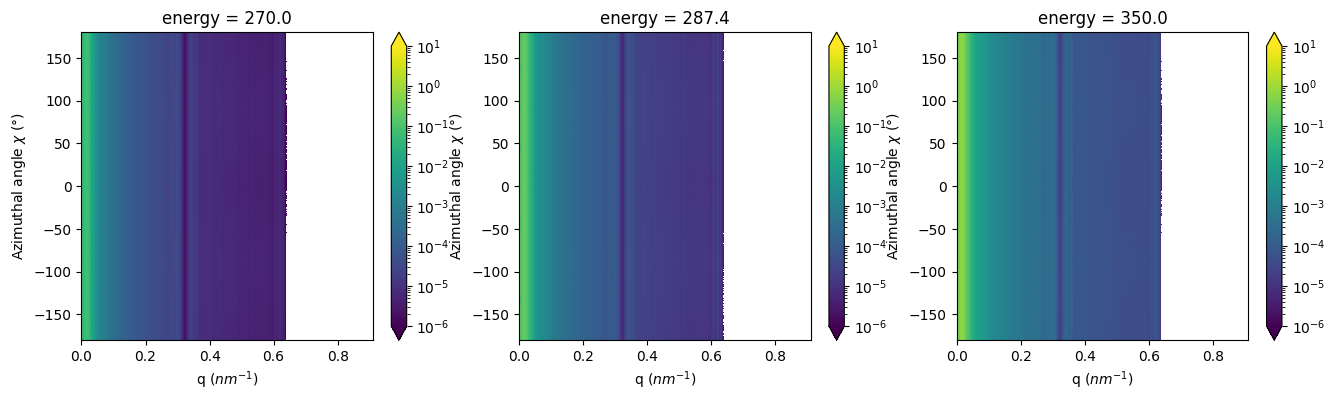

In [87]:
fig, ax = plt.subplots(1,3,figsize=(16,4)) # we'll plot for all 3 energies here
remeshed.sel(energy=270.0).plot(norm=LogNorm(10**-6,10),ax=ax[0])
remeshed.sel(energy=287.4).plot(norm=LogNorm(10**-6,10),ax=ax[1])
remeshed.sel(energy=350.0).plot(norm=LogNorm(10**-6,10),ax=ax[2])
for a in ax:
    a.set_xlabel('q ($nm^{-1}$)')
    a.set_ylabel('Azimuthal angle $\chi$ ($\degree$)')

Plot the integrated scattering like so:

Text(0.5, 1.0, 'Integrated over $\\chi=(-45\\degree,45\\degree)$')

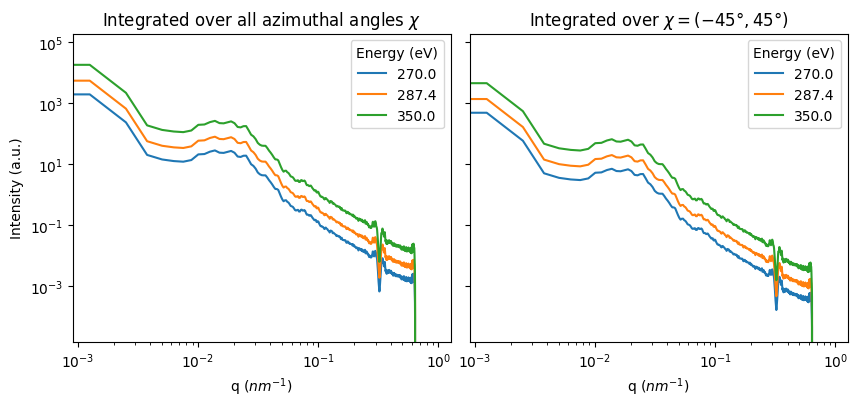

In [107]:
fig, ax = plt.subplots(1,2,figsize=(10,4),sharey=True)
plt.subplots_adjust(wspace=0.05)
xenergies = np.asarray(remeshed.energy)
for e in xenergies:
    remeshed.sel(energy=e).sum('chi').plot(ax = ax[0],label=e)
    remeshed.sel(energy=e).sel(chi=slice(-45,45)).sum('chi').plot(ax=ax[1],label=e)
for a in ax:
    a.loglog()
    a.legend(title='Energy (eV)')
    a.set_xlabel('q ($nm^{-1}$)')
ax[0].set_ylabel('Intensity (a.u.)')
ax[0].set_title('Integrated over all azimuthal angles $\chi$')
ax[1].set_title('Integrated over $\chi=(-45\degree,45\degree)$')


<font size=4>See NRSS tutorial and/or "How to RSoXS" by P.J. Dudenas et. al. *J. Chem. Phys.* 163, 061501 (2025) (https://doi.org/10.1063/5.0267709) for further information on extracting useful quantities from NRSS data.

### Cahn-Hilliard morphology generation

In [109]:
sys.path.append('/home/cbishop/TPD-TCTA/Scripts/')
import rsoxsCahn as ch

In [122]:

qch1 = (0.009,.015); qch2 = (.05,.06)
dim = 1024
fA_TPD = 0.59
fB_TPD = 0.48
cTPD = 0.53
TPD27 = np.empty(shape=(0,0))
TCTA27 = np.empty(shape=(0,0))
mixed_pcts = []
Apcts = []
for i in range(0,4):#range(0,27):
    ctry = ch.gen_spec_CH(c0 = cTPD, W = 0.3, M = 1.0, Npix = dim, Nsteps=1000, rngseed=i)
    # W = 2 and W = 0.3

    final_morph = ctry[-1]
    # final_morph = ctry[-1] - np.min(ctry[-1])
    # final_morph = final_morph / np.max(final_morph) # this brings it to a scale of 0 to 1

    Vfrac_TPD = np.full((dim,dim),fill_value=1.0)
    Vfrac_TPD = Vfrac_TPD*final_morph
    Vfrac_TCTA = np.full((dim,dim),fill_value=1.0)
    Vfrac_TCTA = Vfrac_TCTA - Vfrac_TPD

    Vfrac_TPD = np.expand_dims(Vfrac_TPD, axis=0)
    Vfrac_TCTA = np.expand_dims(Vfrac_TCTA, axis=0)

    if np.shape(TPD27) == (0,0):
        TPD27 = Vfrac_TPD
    else:
        TPD27 = np.concatenate((TPD27, Vfrac_TPD),axis=0)
    if np.shape(TCTA27) == (0,0):
        TCTA27 = Vfrac_TCTA
    else:
        TCTA27 = np.concatenate((TCTA27, Vfrac_TCTA),axis=0)

AFMimage = np.kron(AFM_filters[340],np.ones((2,2)))
vac_filt = np.zeros((4,1024,1024))#np.zeros((27,1024,1024))
for i in range(0,np.shape(AFMimage)[0]):
    for j in range(0,np.shape(AFMimage)[1]):
        if AFMimage[i,j] <= 0:
            vac_filt[-1, i, j] = 1.
            vac_filt[-2, i, j] = np.round(np.abs(AFMimage[i,j])/5. , 3)
        elif AFMimage[i,j] > 0:
            vac_filt[-1, i, j] = np.round((1. - (AFMimage[i,j]/5.)) , 3)
            vac_filt[-2, i, j] = 0.
inverse_vac = np.ones(np.shape(vac_filt)) - vac_filt
TPD27_corr = TPD27*inverse_vac
TCTA27_corr = TCTA27*inverse_vac
dim = 1024
imgsize_nm = 5000.
zeros_mat = np.zeros(np.shape(vac_filt),dtype=float)


returning whole time series
returning whole time series
returning whole time series
returning whole time series


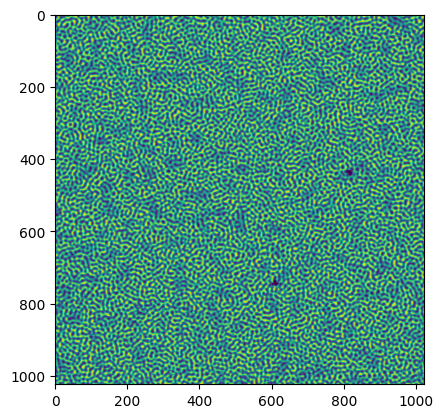

In [125]:
plt.imshow(TPD27_corr[2])

In [196]:
    
matfile_folder='/home/cbishop/TPD-TCTA/'
    
px_nm = float(imgsize_nm/dim)
mat1_consts = OpticalConstants.load_matfile(f'{matfile_folder}Material1.txt',name='Material 1')

mat1 = Material(materialID=1,Vfrac=TPD27_corr,S=zeros_mat, psi=zeros_mat,theta=zeros_mat,energies=energies,
        opt_constants=mat1_consts.opt_constants,name='Material 1')

mat2_consts = OpticalConstants.load_matfile(f'{matfile_folder}Material2.txt',name='Material 2')

mat2 = Material(materialID=2,Vfrac=TCTA27_corr,S=zeros_mat, psi=zeros_mat,theta=zeros_mat,energies=energies,
    opt_constants=mat2_consts.opt_constants,name='Material 2')

mat3 = Material(materialID=3,Vfrac=vac_filt,S=zeros_mat, psi=zeros_mat,theta=zeros_mat,energies=energies,name='vacuum')

morph = Morphology(3,materials={1:mat1,2:mat2,3:mat3},PhysSize=px_nm, create_cy_object=True)
morph.check_materials(quiet=True); morph.EAngleRotation = [0.0, 1.0, 360.0]; morph.WindowingType = 1


Dataset dimensions (Z, Y, X): 27 x 1024 x 1024
Number of Materials: 3

Material 1 Vfrac. Min: 0.0 Max: 0.6735421419143677
Material 1 S. Min: 0.0 Max: 0.0
Material 1 theta. Min: 0.0 Max: 0.0
Material 1 psi. Min: 0.0 Max: 0.0


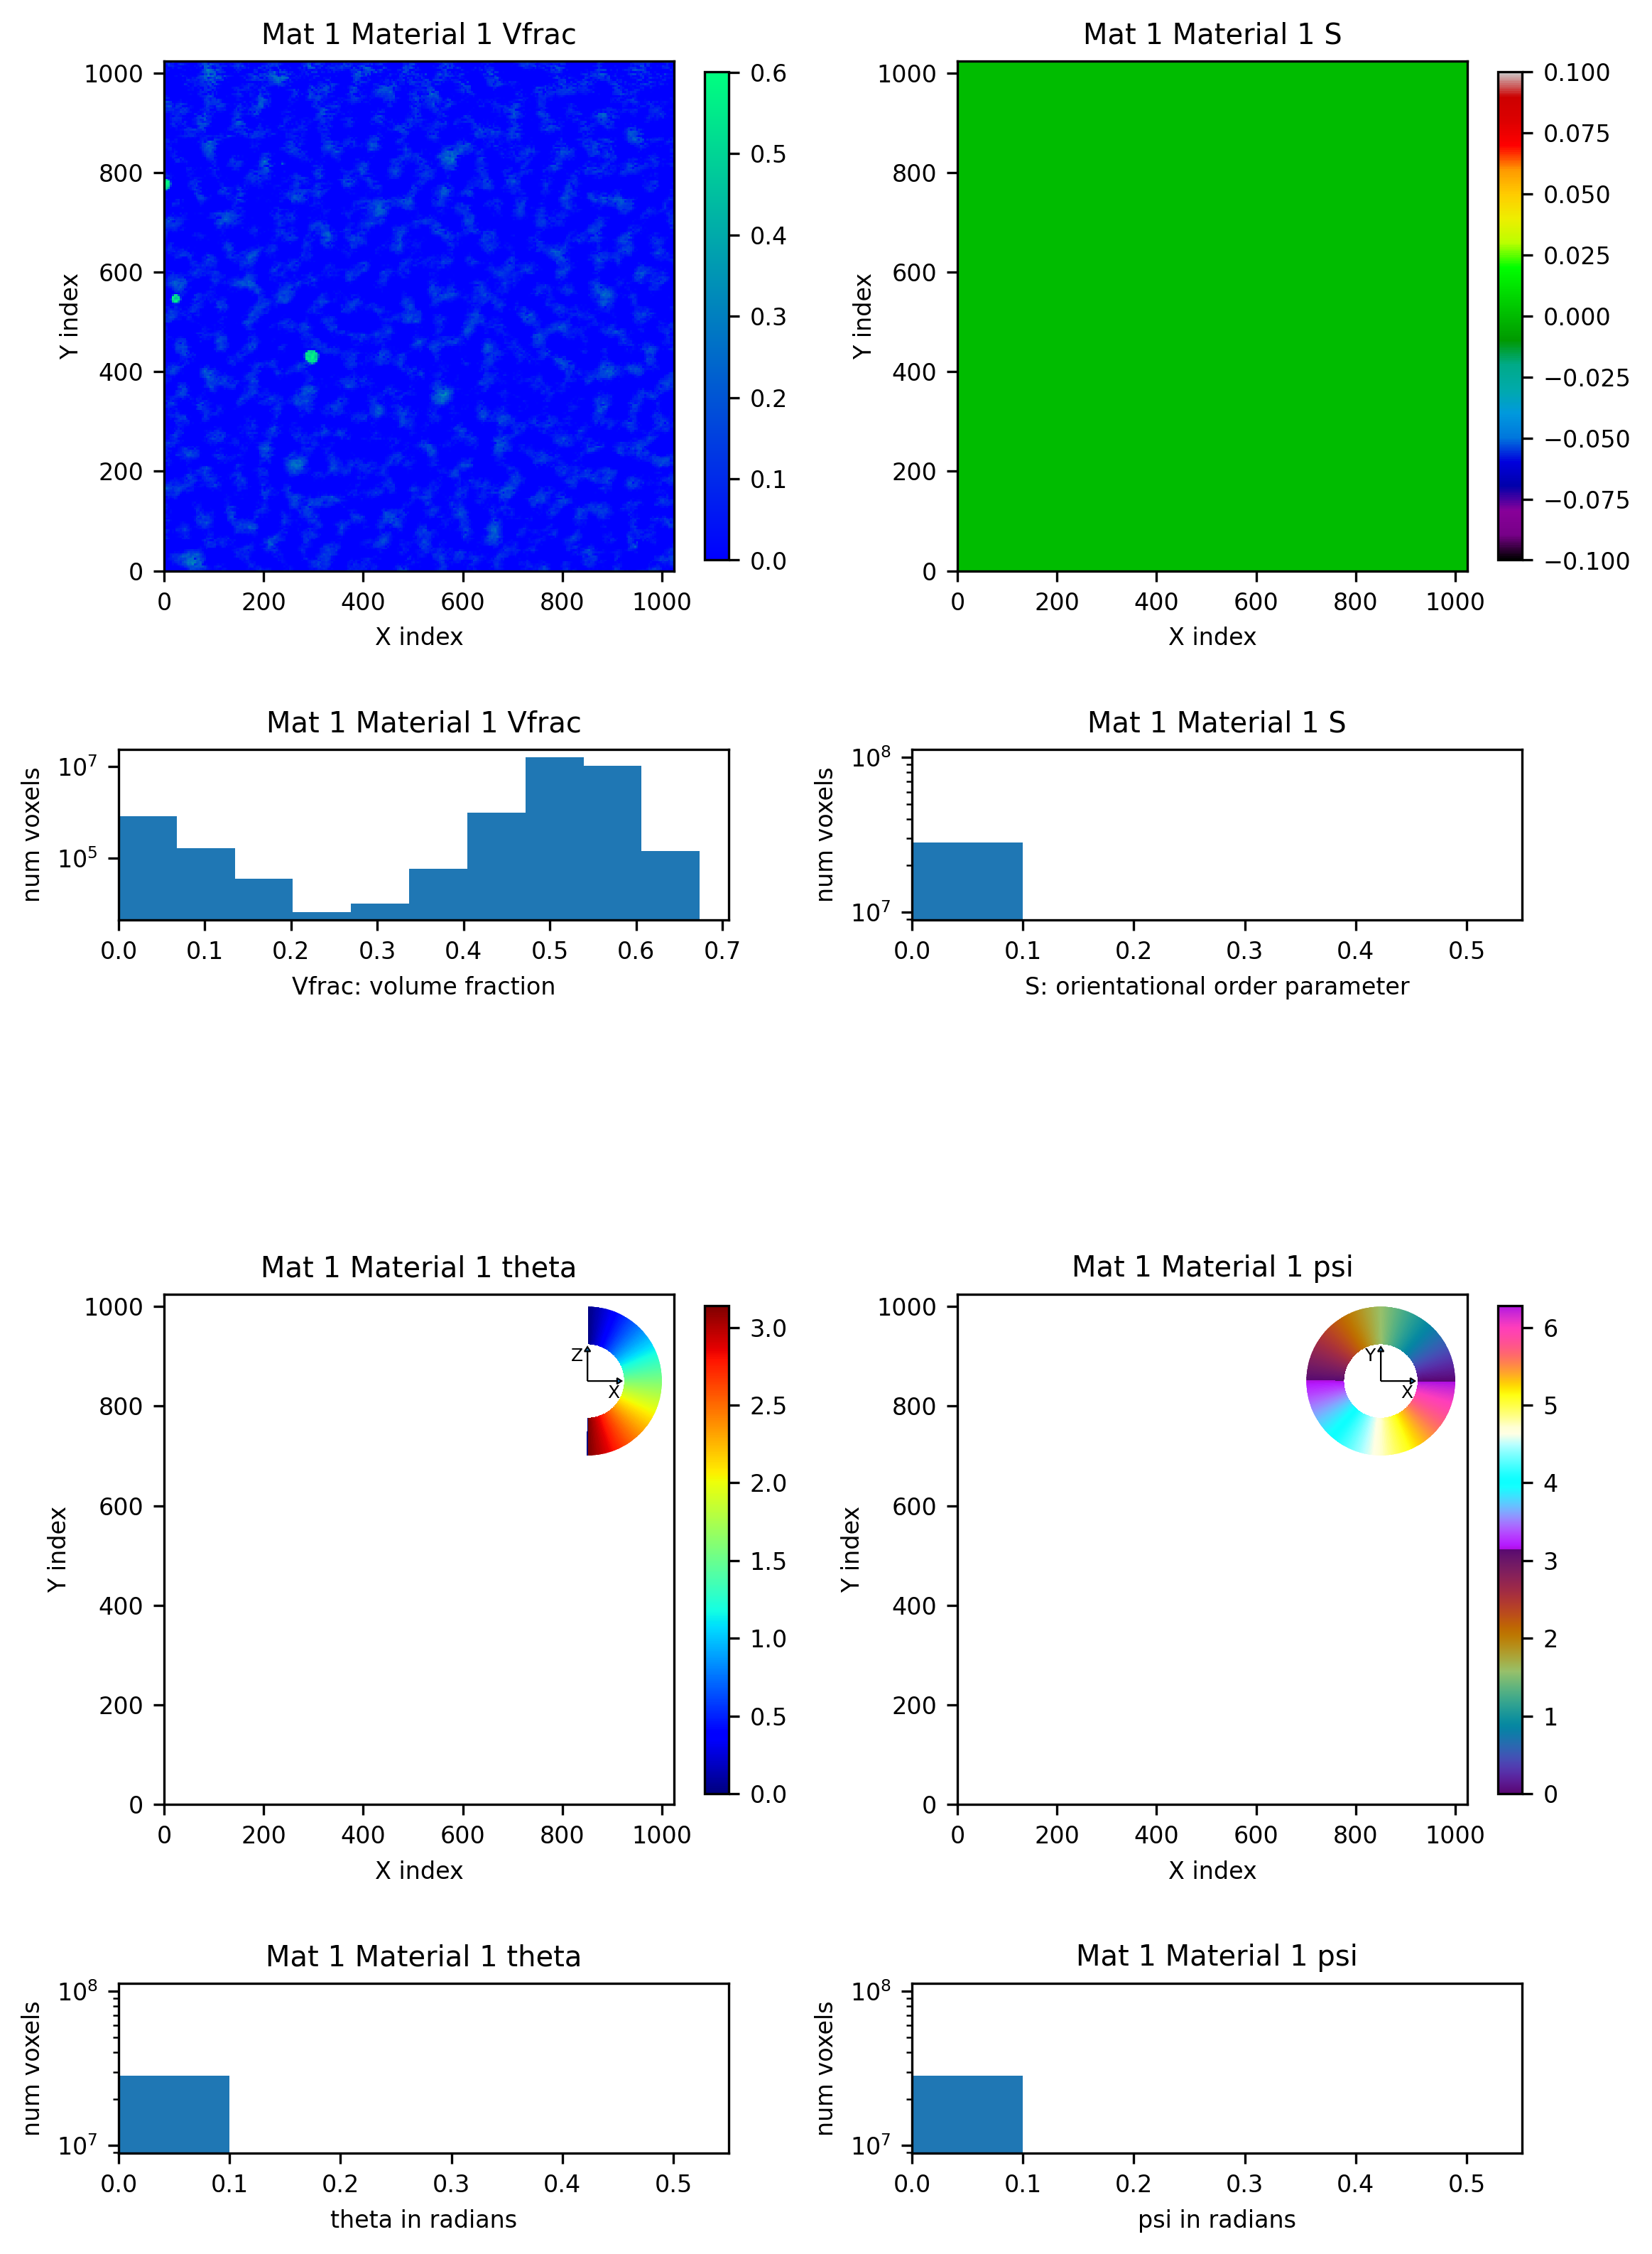

Material 2 Vfrac. Min: 0.0 Max: 0.6347441375255585
Material 2 S. Min: 0.0 Max: 0.0
Material 2 theta. Min: 0.0 Max: 0.0
Material 2 psi. Min: 0.0 Max: 0.0


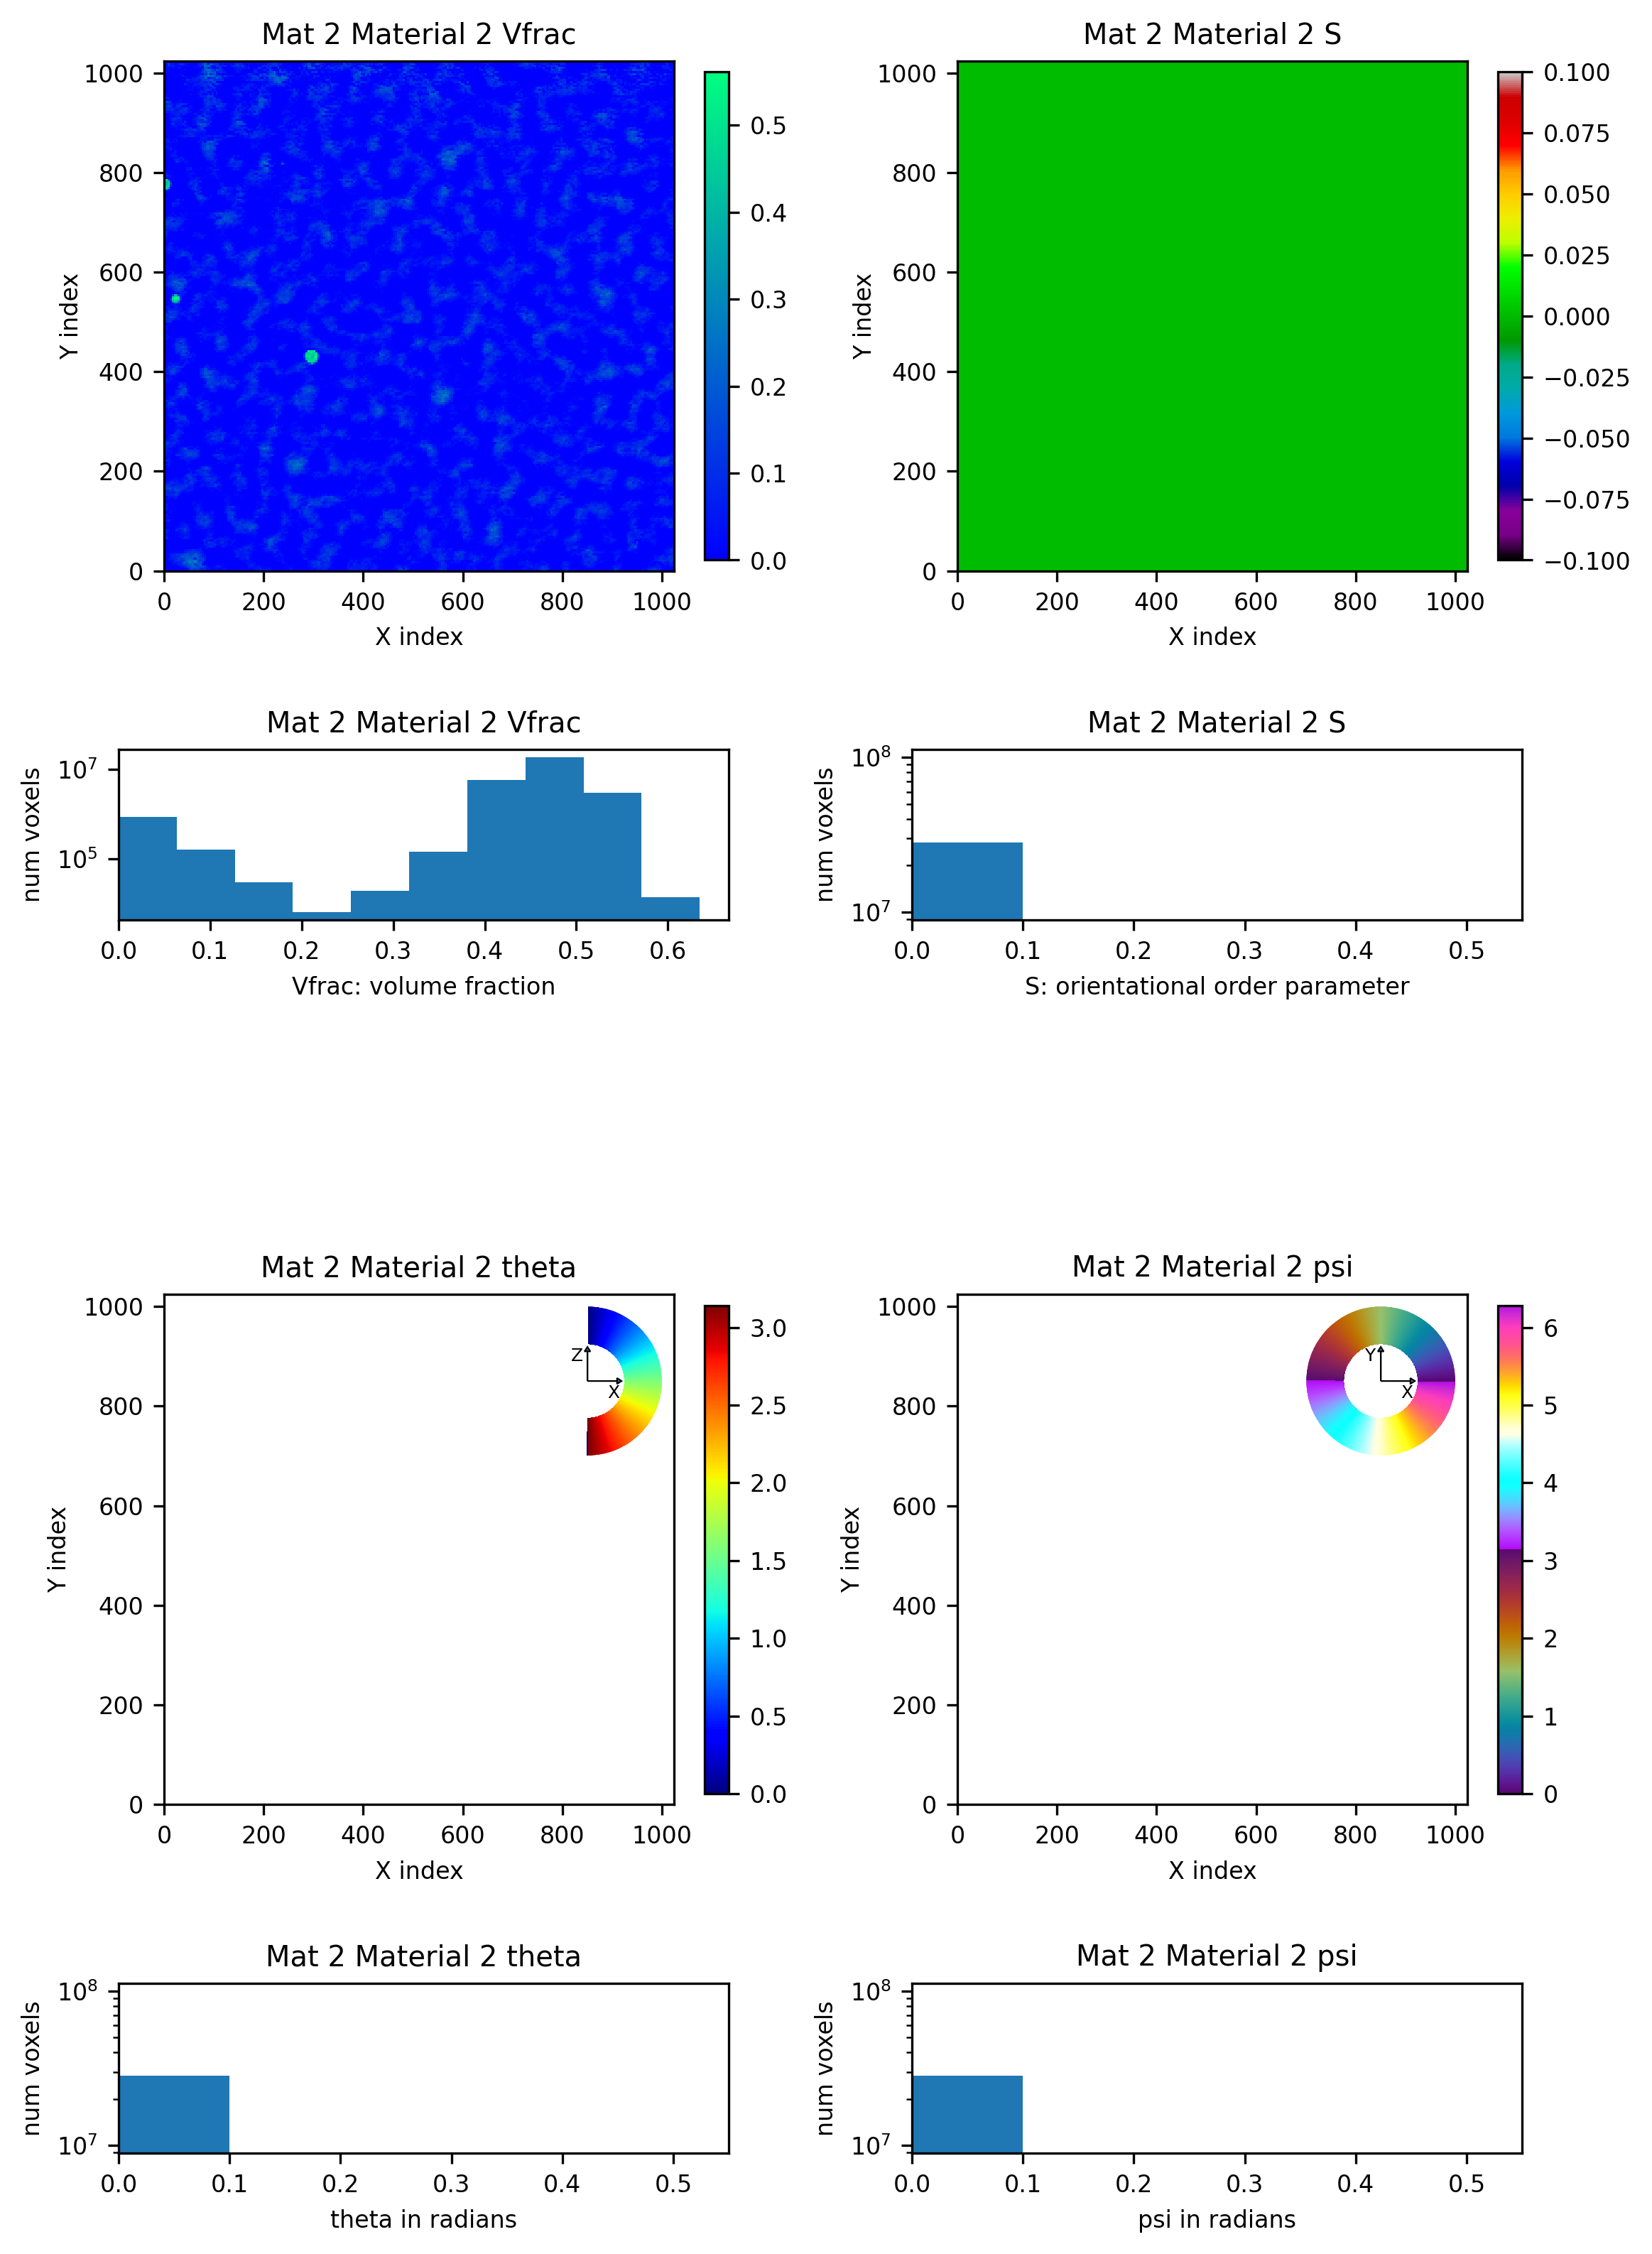

Material 3 Vfrac. Min: 0.0 Max: 1.0
Material 3 S. Min: 0.0 Max: 0.0
Material 3 theta. Min: 0.0 Max: 0.0
Material 3 psi. Min: 0.0 Max: 0.0


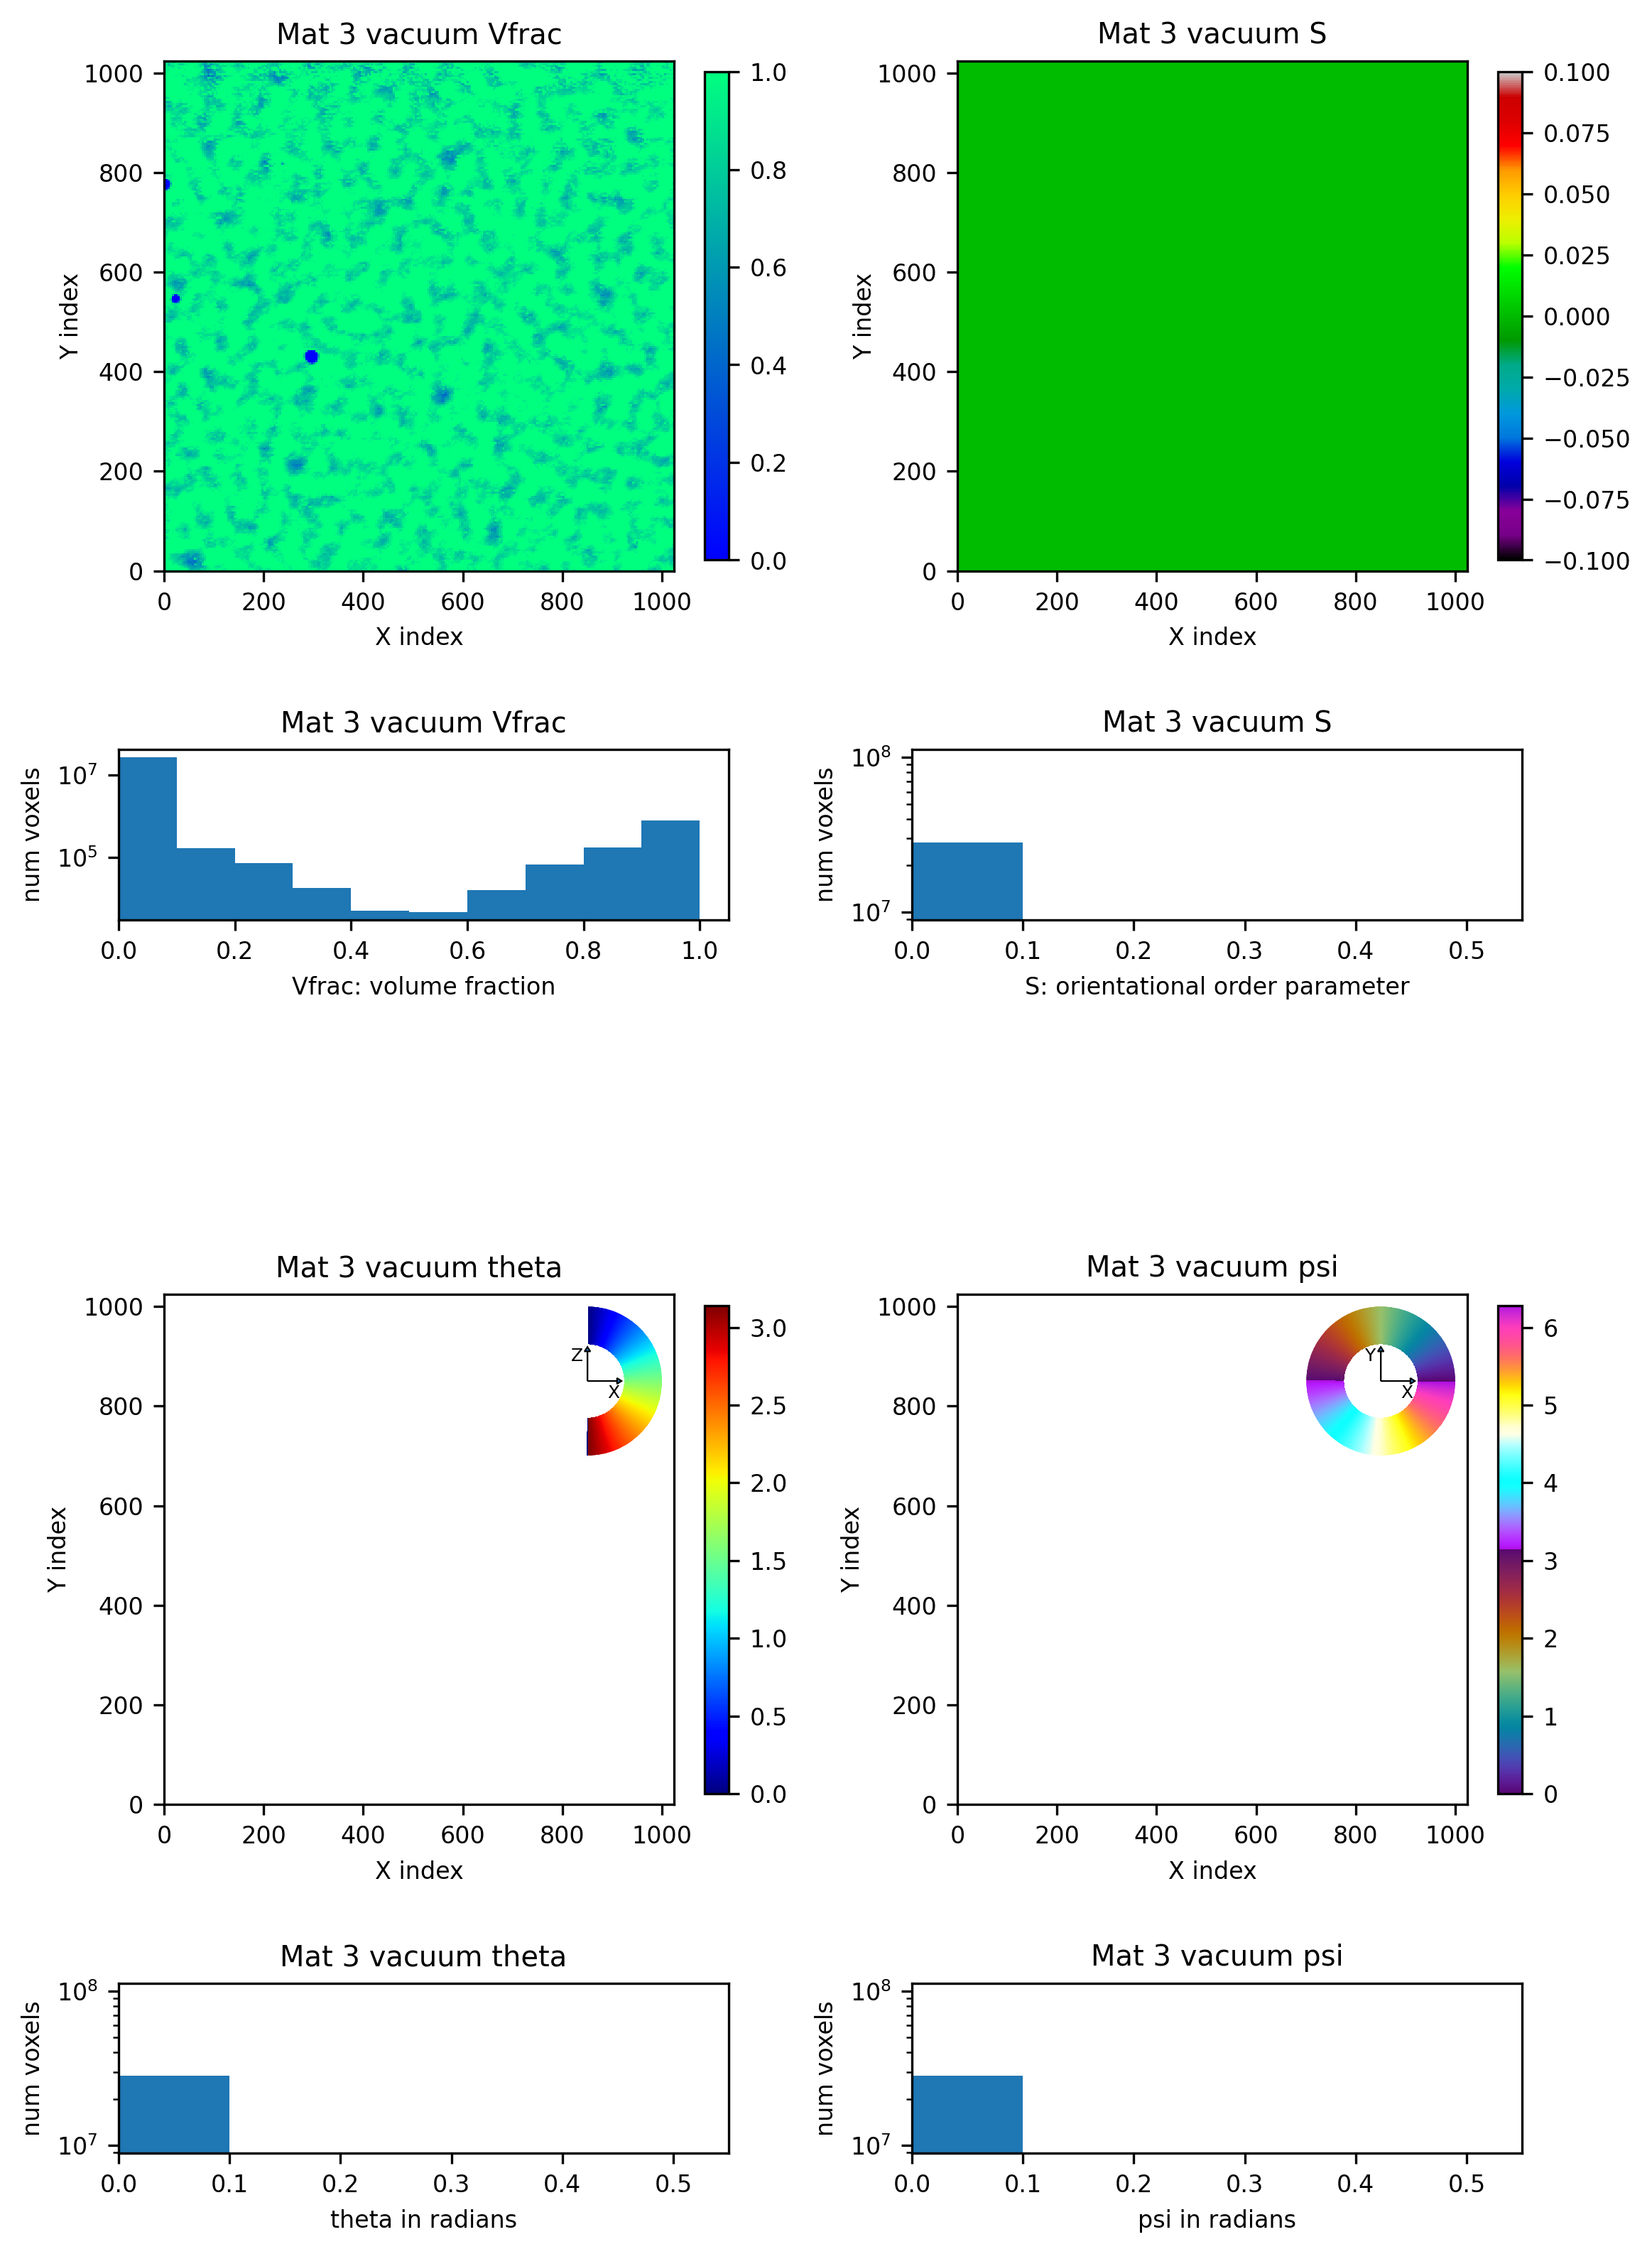

[]

<Figure size 640x480 with 0 Axes>

In [198]:
viz.morphology_visualizer(morph,z_slice=26)

In [199]:
scattering = morph.run()
remeshed = integrator.integrateImageStack(scattering)


 [STAT] Executing: 

Number of CUDA devices:1
[INFO] [GPU = NVIDIA RTX A6000] : 250eV -> 340eV
 [STAT] Energy = 250 starting 
 [STAT] Energy = 260 starting 
 [STAT] Energy = 270 starting 
 [STAT] Energy = 272 starting 
 [STAT] Energy = 274 starting 
 [STAT] Energy = 276 starting 
 [STAT] Energy = 278 starting 
 [STAT] Energy = 280 starting 
 [STAT] Energy = 280.5 starting 
 [STAT] Energy = 281 starting 
 [STAT] Energy = 281.5 starting 
 [STAT] Energy = 282 starting 
 [STAT] Energy = 282.5 starting 
 [STAT] Energy = 283 starting 
 [STAT] Energy = 283.2 starting 
 [STAT] Energy = 283.4 starting 
 [STAT] Energy = 283.6 starting 
 [STAT] Energy = 283.8 starting 
 [STAT] Energy = 284 starting 
 [STAT] Energy = 284.2 starting 
 [STAT] Energy = 284.4 starting 
 [STAT] Energy = 284.6 starting 
 [STAT] Energy = 284.8 starting 
 [STAT] Energy = 285 starting 
 [STAT] Energy = 285.2 starting 
 [STAT] Energy = 285.4 starting 
 [STAT] Energy = 285.6 starting 
 [STAT] Energy = 285.8 starting 
 [STAT

 96%|███████████████████████████████████████████████████████████████████████████████   | 80/83 [00:00<00:00, 157.48it/s]/home/cbishop/anaconda3/envs/spm_soft/lib/python3.11/site-packages/xarray/core/concat.py:500: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
100%|██████████████████████████████████████████████████████████████████████████████████| 83/83 [00:00<00:00, 143.01it/s]


In [201]:

plt.close()

dpi = 200
fontsize = 6
params = {
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "legend.fontsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "lines.linewidth": 1,
    "lines.markersize": 1.
}
plt.rcParams.update(params)
fig = plt.figure(figsize=(10.,6.), dpi=dpi) # widthxheight in inches - double column figure (7 inch width limit, 9.167 inch height limit BUT includes caption)

gs_morph = plt.GridSpec(4,4,left=0.1,right=0.45,wspace=0,bottom=0.1)
ax1 = fig.add_subplot(gs_morph[0:2,0:2])
ax2 = fig.add_subplot(gs_morph[0:2,2:4])
axISI1 = fig.add_subplot(gs_morph[2:4,0:2])
axISI2 = fig.add_subplot(gs_morph[2:4,2:4])
#ax4 = fig.add_subplot(gs_morph[1,1])
gs_scattering = plt.GridSpec(3,2,left=0.5, right=0.9,bottom=0.1,hspace=0.3)
ax_sc = fig.add_subplot(gs_scattering[0:2,:])
ax_sum = fig.add_subplot(gs_scattering[2:,:])

cb = ax1.imshow(morph.materials[1].Vfrac[23]); ax1.set_title('$V_{frac}$ TPD (interior)')
plt.colorbar(cb,ax=ax1,shrink=0.8,location='bottom',pad=0)
cb = ax2.imshow(morph.materials[2].Vfrac[23]); ax2.set_title('$V_{frac}$ TCTA (interior)')
plt.colorbar(cb,ax=ax2,shrink=0.8,location='bottom',pad=0)


for a in [ax1,ax2]:
    a.set_xticks([])
    a.set_yticks([])
ISIs1 = []
ISIs2 = []
pcol = iter(cm.rainbow(np.linspace(0,1,len(energies))))
for e in energies:
    remeshed.sel(energy=e).mean('chi').plot(label=str(e),color=next(pcol),ax=ax_sc)
    Iqarr = remeshed.sel(energy=e,method='nearest').mean('chi')
    q = np.asarray(Iqarr['q'])
    I = np.asarray(Iqarr)
    tosave = np.column_stack((q,I))
    np.savetxt(f'/home/cbishop/TPD-TCTA/SimResults_2025/20250316/model1_Wpt3_{round(e,2)}eV.txt',tosave)
    #ax.plot(q,I,'o',markersize=1.5,color=next(pcol),label=e)
    da = xr.DataArray(data = I, coords=[q], dims=['q'])
    danew = da.sortby(da['q'])
    q2 = np.asarray(danew['q']**2)
    Iq2 = danew*q2
    ISI = float(Iq2.where(Iq2['q'] > qch1[0]).where(Iq2['q'] < qch1[1]).dropna(dim='q').integrate(coord='q'))
    ISIs1.append(ISI)
    ISI = float(Iq2.where(Iq2['q'] > qch2[0]).where(Iq2['q'] < qch2[1]).dropna(dim='q').integrate(coord='q'))
    ISIs2.append(ISI)
ax_sc.loglog()
ax_sc.legend(bbox_to_anchor=(1,1), ncol=3,fontsize=9)

axISI1.plot(energies,ISIs1,'-o',markersize=2)
axISI2.plot(energies,ISIs2,'-o',markersize=2)
axISI1.semilogy(); axISI2.semilogy()
axISI1.set_title(f'Low q {qch1}'); axISI2.set_title(f'Med q {qch2}')

ax_sum.set_title(f'+/- {round(np.std(Apcts),1)} % A in the non-mixed phase')
ax_sum.plot(Apcts,'-o')
ax_sum.set_xlabel('layer')
ax_sum.set_ylabel('% nucleated phase A')
ax_sum.axhline(45)

fig.text(0.1, 0.05, f'{m} Steps')
plt.savefig(f'/home/cbishop/TPD-TCTA/SimResults_2025/20250316/Images/model1_wpt3.png',bbox_inches='tight',dpi=dpi)
plt.close()

/home/cbishop/anaconda3/envs/spm_soft/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/cbishop/anaconda3/envs/spm_soft/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/cbishop/anaconda3/envs/spm_soft/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
